<a href="https://colab.research.google.com/github/lunaaboytes/M-todos-num-ricos-2/blob/main/Integraci%C3%B3n_de_Romberg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Integración de Romberg para $\int_0^\pi sen{(x)}dx$

In [27]:
import numpy as np
import matplotlib.pyplot as plt

Algoritmo 4.2 de Burden

In [28]:
def romberg(f, a, b, n):
    R = np.zeros((n, n))
    h = b - a
    R[0, 0] = h / 2 * (f(a) + f(b))
    for i in range(1, n):
        suma = 0
        for k in range(1, 2**(i-1) + 1):
            suma += f(a + (k - 0.5) * h)
        R[i, 0] = 0.5 * (R[i-1, 0] + h * suma)
        for j in range(1, i + 1):
            R[i, j] = R[i, j-1] + (R[i, j-1] - R[i-1, j-1]) / (4**j - 1)
        h = h / 2
    return R


In [29]:
f=lambda x: np.sin(x)
a=0
b=np.pi
n=6
R=romberg(f,a,b,n)
print("Romberg\n")

Romberg



In [30]:
for i in range(n):
  print(" ".join(f"{R[i,j]:.8f}" for j in range(i+1)))

0.00000000
1.57079633 2.09439510
1.89611890 2.00455975 1.99857073
1.97423160 2.00026917 1.99998313 2.00000555
1.99357034 2.00001659 1.99999975 2.00000002 1.99999999
1.99839336 2.00000103 2.00000000 2.00000000 2.00000000 2.00000000


In [31]:
resultado=R[-1,-1]

In [32]:
print("\nResultado:", f"{resultado:.8f}")
print(f"valor exacto: {2.0:.8f}")
print("error absoluto:", f"{abs(2- resultado):.8e}")



Resultado: 2.00000000
valor exacto: 2.00000000
error absoluto: 1.32116540e-12


Insertando la grafica

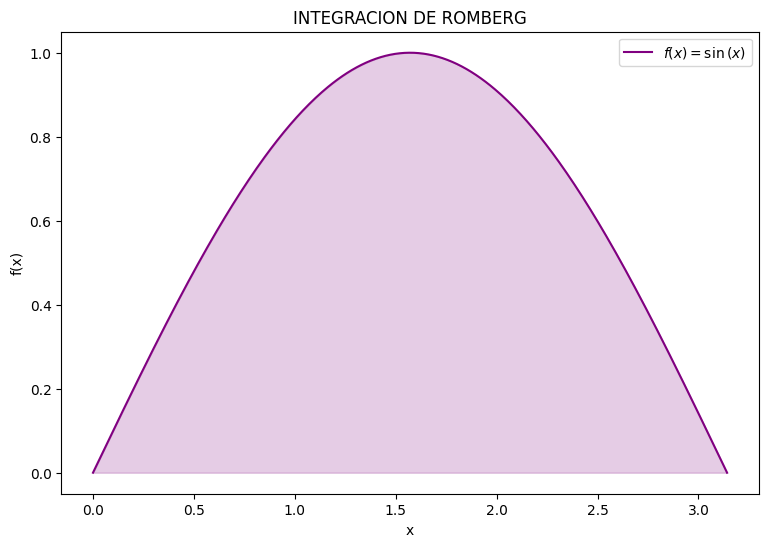

In [33]:
x=np.linspace(0,np.pi,400)
plt.figure(figsize=(9,6))
plt.plot(x,np.sin(x),label=r"$f(x)=\sin{(x)}$",color="purple")
plt.fill_between(x,np.sin(x),alpha=0.2, color="purple")
plt.title("INTEGRACION DE ROMBERG")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()